In [12]:
import numpy as np
import pandas as pd
%matplotlib inline

In [13]:
df=pd.read_csv("/Users/deepanshus/StockMarketPredictor/Project/data/Combined/all/1.csv")

In [14]:
df.head()

,rsi,macd,sma_ratio,volume_change,volatility,target
0,52.729384,5.231607,1.041503,-0.764616,0.015705,-0.009905
1,54.632972,5.343971,1.040495,-0.387146,0.015875,0.033691
2,68.850806,6.284495,1.044956,3.874652,0.015084,-0.028466
3,57.588533,6.152034,1.046341,-0.729922,0.018880,-0.012892
4,53.169572,5.627148,1.046767,-0.136228,0.019619,0.000297


In [15]:
df['target'].value_counts()

target
 0.000000    267
-0.050000      6
-0.050000      6
 0.012048      5
 0.003984      4
            ... 
 0.014014      1
 0.020411      1
-0.000376      1
 0.003325      1
-0.011997      1
Name: count, Length: 51702, dtype: int64

### 📊 Target Variable Distribution

Before building any model, it is important to understand how the target variable is distributed.

This helps identify whether the dataset is balanced or imbalanced, which directly affects model performance.

**Insight Goal:**

* Check class balance
* Understand prediction difficulty


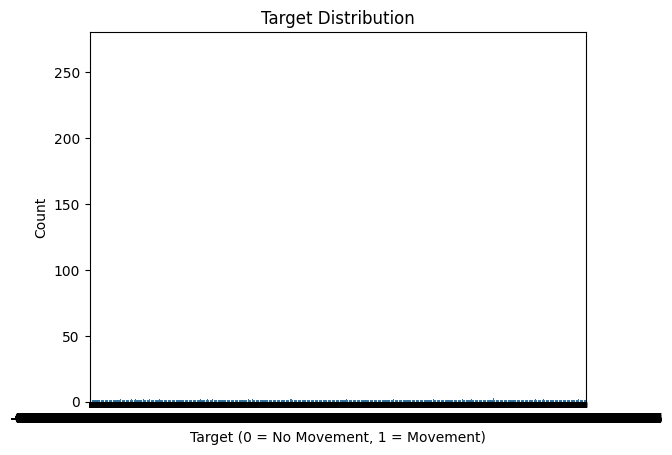

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x=df["target"])
plt.title("Target Distribution")
plt.xlabel("Target (0 = No Movement, 1 = Movement)")
plt.ylabel("Count")
plt.show()

### 📈 Feature Distributions

Understanding how each feature is distributed helps identify skewness, spread, and potential anomalies.

**Insight Goal:**

* Detect skewness
* Identify unusual distributions


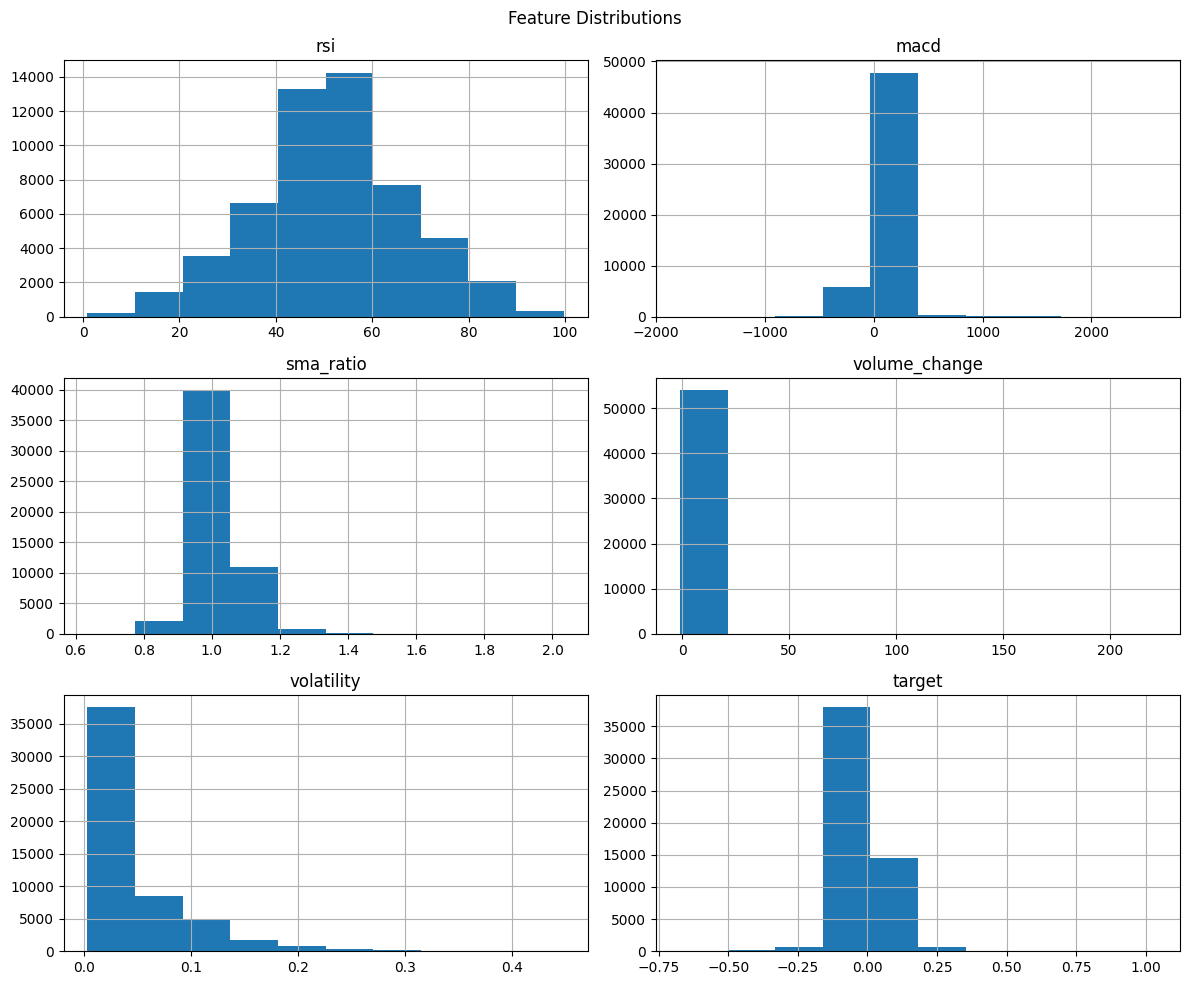

In [17]:
df.hist(figsize=(12,10))
plt.suptitle("Feature Distributions")
plt.tight_layout()
plt.show()

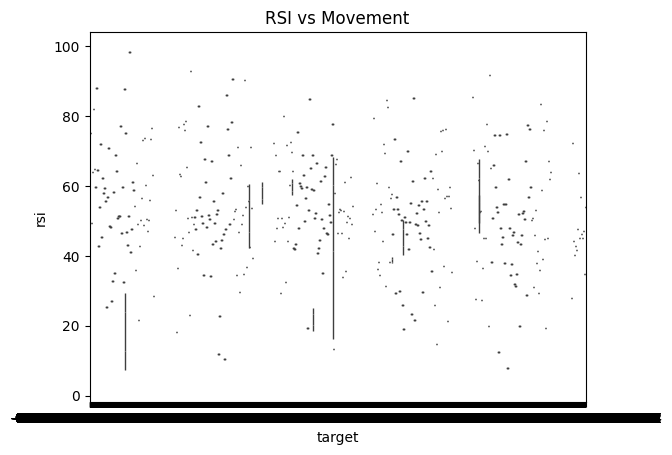

In [18]:
sample_df = df.sample(5000, random_state=42)

sns.boxplot(x='target', y='rsi', data=sample_df)
plt.title("RSI vs Movement")
plt.show()

### 📦 Outlier Detection

Boxplots are used to detect extreme values (outliers) that may affect model performance.

**Insight Goal:**

* Identify noisy or extreme values
* Understand spread of data


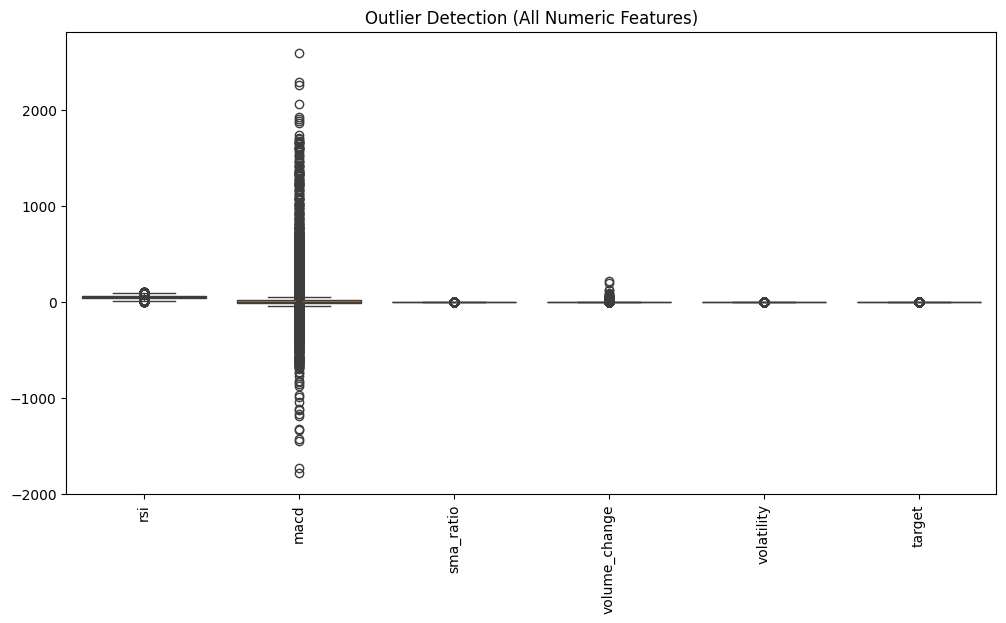

In [20]:
num_cols = df.select_dtypes(include=['int64','float64']).columns

plt.figure(figsize=(12,6))
sns.boxplot(data=df[num_cols])
plt.xticks(rotation=90)
plt.title("Outlier Detection (All Numeric Features)")
plt.show()

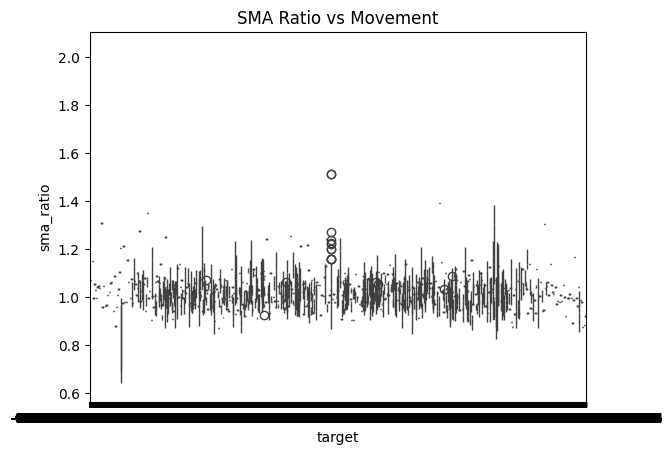

In [ ]:
sns.boxplot(x='target', y='sma_ratio', data=df)
plt.title("SMA Ratio vs Movement")
plt.show()

### 🔍 RSI vs Target

This plot compares RSI values across target classes to evaluate its predictive strength.

**Insight Goal:**

* Check if RSI differs across classes
* Evaluate its usefulness as a feature


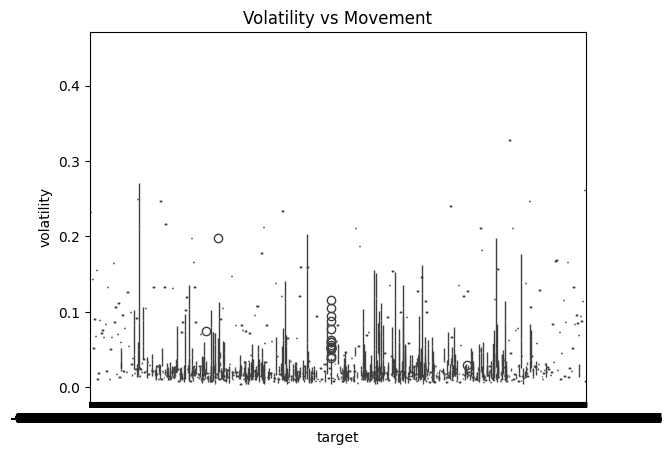

In [ ]:
sns.boxplot(x='target', y='volatility', data=df)
plt.title("Volatility vs Movement")
plt.show()

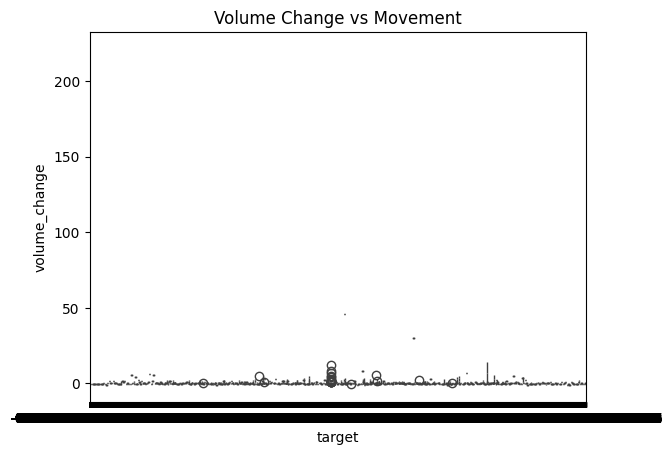

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x='target', y='rsi', data=df, palette='Set2')
sns.stripplot(x='target', y='rsi', data=df, color='black', alpha=0.3)

plt.title("RSI vs Target Movement")
plt.show()

### 📊 MACD vs Target

MACD helps capture trend direction. This plot shows how MACD varies across target classes.

**Insight Goal:**

* Analyze trend differences
* Validate MACD as a predictor


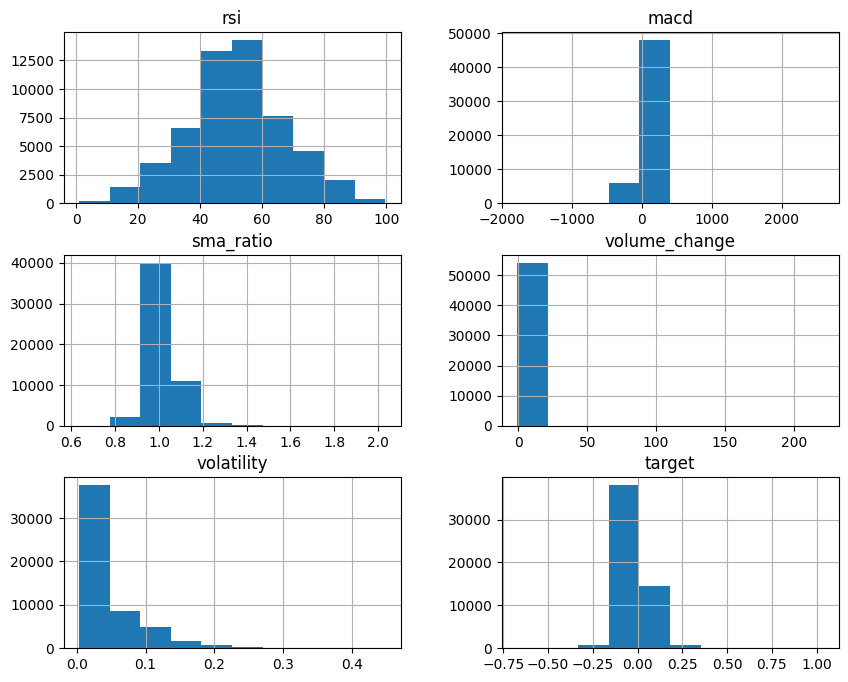

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x='target', y='rsi', data=df, palette='Set2')
sns.stripplot(x='target', y='rsi', data=df, color='black', alpha=0.3)

plt.title("RSI vs Target Movement")
plt.show()

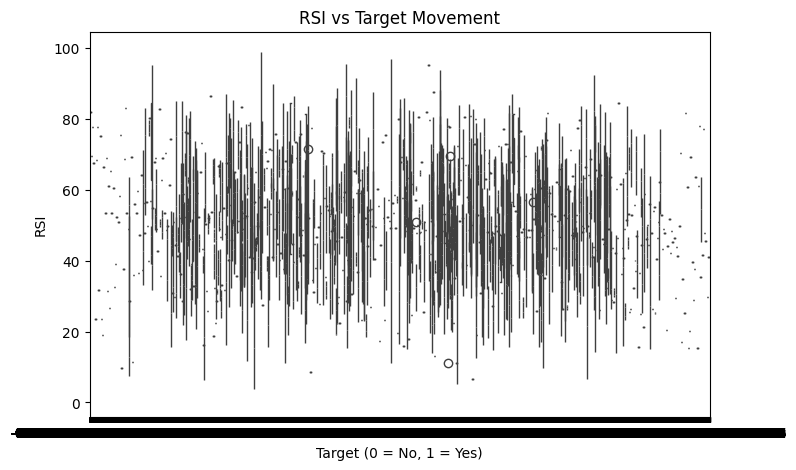

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.boxplot(x='target', y='rsi', data=df)

plt.title("RSI vs Target Movement")
plt.xlabel("Target (0 = No, 1 = Yes)")
plt.ylabel("RSI")

plt.show()

### 📊 MACD vs Target

MACD helps capture trend direction. This plot shows how MACD varies across target classes.

**Insight Goal:**

* Analyze trend differences
* Validate MACD as a predictor


/var/folders/g8/43rm_8rs5wbchfhhkxt_832c0000gn/T/ipykernel_93690/2217592029.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='target', y='macd', data=df, palette='coolwarm')


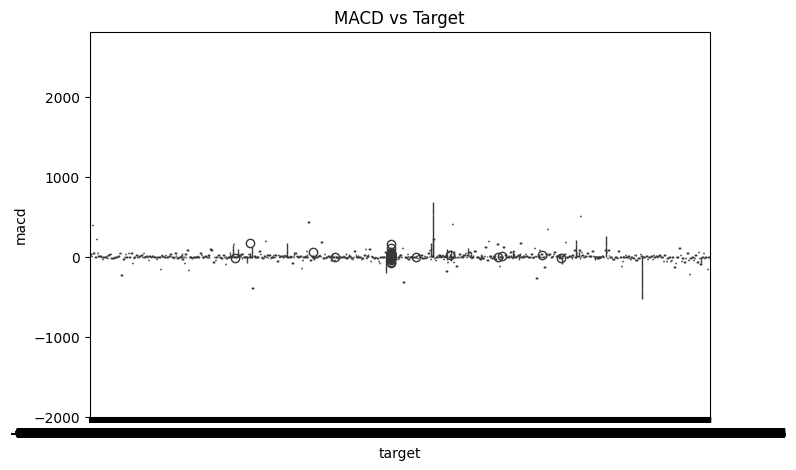

In [21]:
plt.figure(figsize=(8,5))
sns.boxplot(x='target', y='macd', data=df, palette='coolwarm')
plt.title("MACD vs Target")
plt.show()

### 📊 Volume vs Target

Trading volume indicates market participation and strength of movement.

**Insight Goal:**

* Understand if higher volume leads to stronger movement


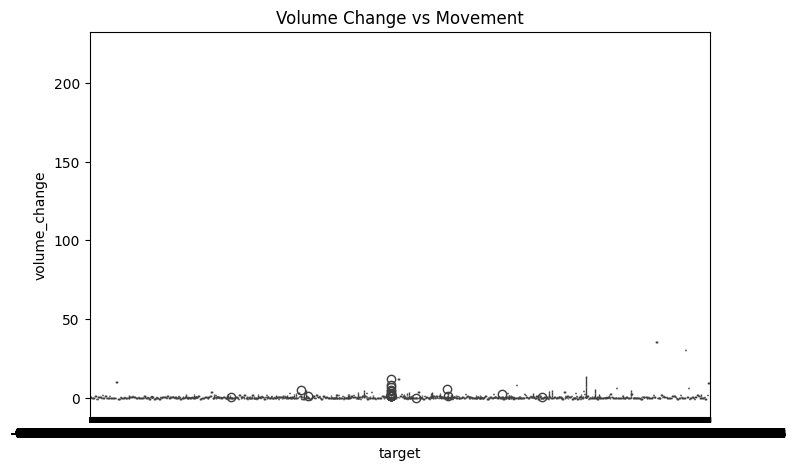

In [25]:
plt.figure(figsize=(8,5))
sns.boxplot(x='target', y='volume_change', data=df)
plt.title("Volume Change vs Movement")
plt.show()

### 📊 Volatility vs Target

Volatility reflects price fluctuations and market uncertainty.

**Insight Goal:**

* Determine if higher volatility correlates with movement


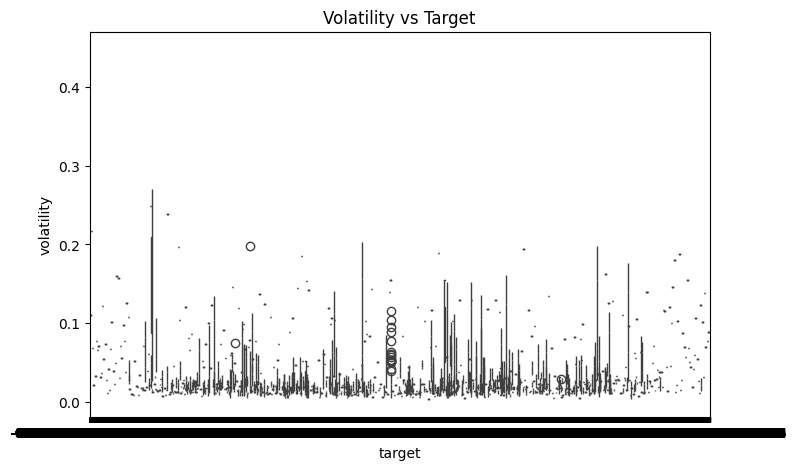

In [22]:
plt.figure(figsize=(8,5))
sns.boxplot(x='target', y='volatility', data=df)
plt.title("Volatility vs Target")
plt.show()

### 🔗 Feature Relationships

Scatter plots help visualize relationships between features and detect patterns.

**Insight Goal:**

* Identify relationships between indicators
* Detect clustering patterns


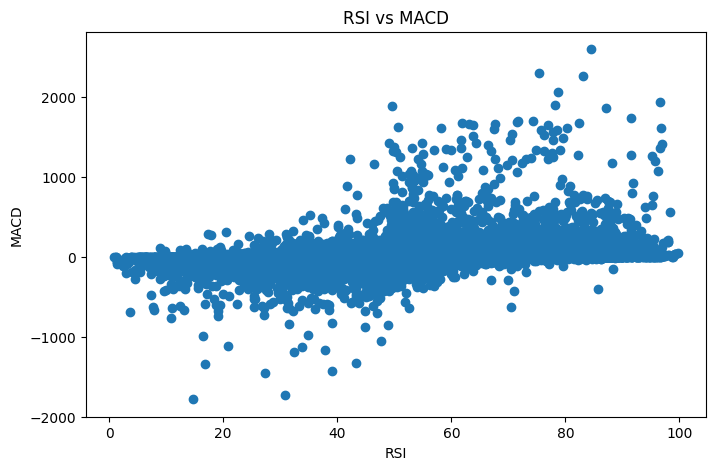

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(df["rsi"], df["macd"])
plt.xlabel("RSI")
plt.ylabel("MACD")
plt.title("RSI vs MACD")
plt.show()

### 🔥 Correlation Analysis

Correlation heatmap helps identify relationships between numerical features.

**Insight Goal:**

* Detect feature dependencies
* Identify redundancy


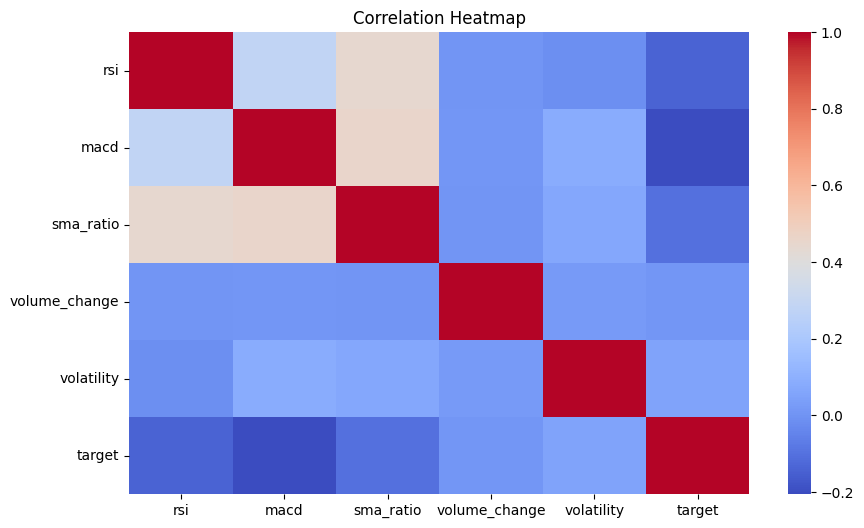

In [ ]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()